# Ovarian cancer SELDI-TOF mass spectrometry: selection with its caveats

The FDA-NCI post-QAQC serum proteomics spectra: 216 samples (121 ovarian
cancer, 95 normal), raw m/z axes binned onto a 4096-point grid over 700 to
12000 Da (the loader documents the binning: aggregation of measured points,
never fabrication).

Two things make this dataset the right hard case. It is notoriously
separable, so any method looks good on AUC and the real questions are
stability and honesty. And its batch/calibration artefacts drove a famous
reproducibility controversy: a selected m/z band here is a candidate
ARTEFACT DETECTOR as much as a biomarker, which is precisely the situation
RSM's reporting machinery (verdicts, support, MNAR stamps, refusals) is
built for. This notebook also demonstrates detection-limit censoring and
missing labels on real spectra (both imposed, both labelled as such).

In [1]:
import sys
sys.path.insert(0, "../benchmarks")
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_ovarian

X, V, y, meta = load_ovarian()
mz = np.linspace(700, 12000, X.shape[-1])
print(X.shape, "cancer:", int(y.sum()), "normal:", int(len(y) - y.sum()))
print(meta["note"])

(216, 1, 4096) cancer: 121 normal: 95
known batch/calibration artefact caveats; see docstring


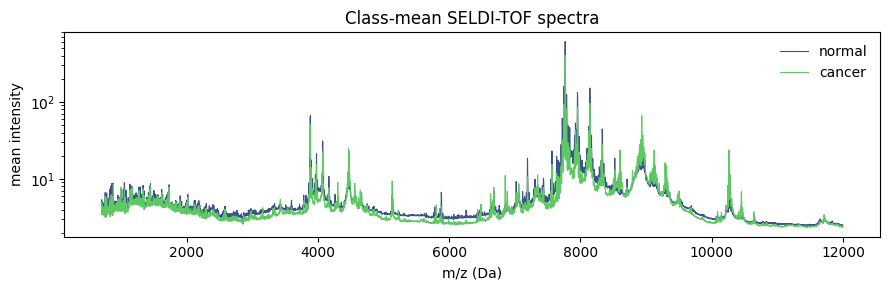

In [2]:
# class-mean spectra (log scale; SELDI intensities span decades)
fig, ax = plt.subplots(figsize=(9, 3))
for cls, shade, name in ((0, 0.25, "normal"), (1, 0.75, "cancer")):
    ax.semilogy(mz, X[y == cls, 0].mean(axis=0),
                color=plt.cm.viridis(shade), lw=0.8, label=name)
ax.set_xlabel("m/z (Da)")
ax.set_ylabel("mean intensity")
ax.legend(frameon=False)
ax.set_title("Class-mean SELDI-TOF spectra")
plt.tight_layout()

## Stable m/z bands with the full honesty report

In [3]:
from robustsignalmaker import BootstrapMaskSelector

sel = BootstrapMaskSelector(task="binary", segment=64, lam=0.08,
                            n_bootstrap=50, target_coverage=6 / 64,
                            seed=0).fit(X, y, V)
for s in sel.selected_segments_:
    pts = sel.grid.segments_to_points([s])
    print(f"segment {s}: {mz[pts[0]]:.0f} to {mz[pts[-1]]:.0f} Da, "
          f"pi={sel.pi_[s]:.2f}, support={sel.support_[s]:.2f}")
sel.stability_report()

segment 24: 4939 to 5112 Da, pi=0.92, support=1.00
segment 31: 6175 to 6349 Da, pi=0.68, support=1.00
segment 43: 8294 to 8468 Da, pi=0.92, support=1.00
segment 44: 8471 to 8644 Da, pi=0.94, support=1.00
segment 54: 10237 to 10411 Da, pi=0.70, support=1.00
segment 62: 11650 to 11823 Da, pi=0.92, support=1.00


{'n_fits': 50,
 'n_failed_fits': 0,
 'tau': 0.68,
 'coverage': 0.09375,
 'assessable_universe': 64,
 'n_segments': 64,
 'unassessable_fraction': 0.0,
 'insufficient_evidence': [],
 'pi_mean': 0.1625,
 'pi_max': 0.94,
 'frac_confident_in': 0.0625,
 'frac_confident_out': 0.765625,
 'ambiguous_fraction': 0.171875,
 'mean_obs_frac': 1.0,
 'strata': 'stratified by class',
 'degenerate': False}

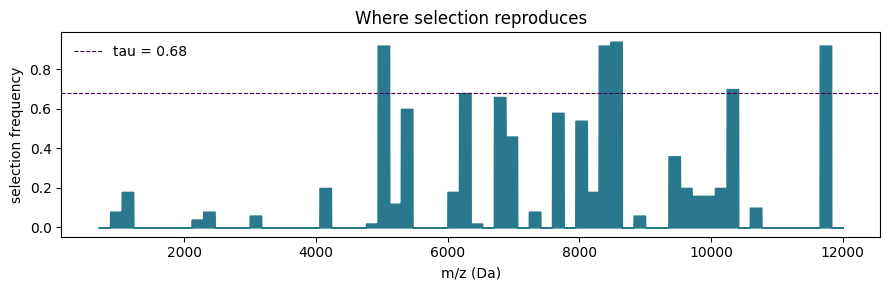

In [4]:
# the stability map over the m/z axis
fig, ax = plt.subplots(figsize=(9, 3))
pi_points = sel.pi_points()
ax.fill_between(mz, 0, np.nan_to_num(pi_points), color=plt.cm.viridis(0.4))
ax.axhline(sel.tau_, color=plt.cm.viridis(0.0), lw=0.8, ls="--",
           label=f"tau = {sel.tau_:.2f}")
ax.set_xlabel("m/z (Da)")
ax.set_ylabel("selection frequency")
ax.legend(frameon=False)
ax.set_title("Where selection reproduces")
plt.tight_layout()

## The honest generalisation verdict

On this dataset high AUC is cheap; the claim worth making is `preserved`
at under a tenth of the axis (6 of 64 segments), with the per-fold MNAR stamps along for the
ride. Remember the provenance caveat: reproducible separation here may
reflect the processing artefacts the literature documented, so the verdict
is about THIS dataset, not about ovarian cancer.

In [5]:
from robustsignalmaker import NestedCV

res = NestedCV(k_outer=5, segment=64, lam=0.08, n_bootstrap=25,
               target_coverage=6 / 64, mnar_permutations=60,
               random_state=0).run(X, y, V)
s = res.summary()
{k: s[k] for k in ("score_name", "score_mean", "verdict",
                    "baseline_score_mean", "selection_stability_adjusted",
                    "missingness_informative", "n_refused_predictions")}

C:\Users\Amanda\AppData\Roaming\Python\Python39\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


{'score_name': 'AUC',
 'score_mean': 0.9829298245614035,
 'verdict': 'preserved',
 'baseline_score_mean': 0.9949122807017543,
 'selection_stability_adjusted': 0.7704160190722058,
 'missingness_informative': False,
 'n_refused_predictions': 0}

## Detection limits as censoring (imposed)

Suppose the detector saturated at the 99th intensity percentile.
`mask_saturation_censor` clips the value (what a real file would contain)
AND marks it missing, so the tallest peak tips become partially observed
evidence instead of fabricated plateaus. At 1% censoring the resample
support stays full, and the effect shows in the per-segment observed
validity (the tips lose points) and in which bands survive selection. Read
the two printouts below together, because they do NOT line up: the bands
that lost standing are not the most-clipped ones, and the second-most-clipped
segment actually gained standing. So on this dataset 1% censoring does not
prune the clipped bands; it perturbs the fit enough to reshuffle the marginal
ones. That is a statement about how thin the margin is between the sixth and
seventh candidate here, not evidence of a clipping mechanism.

In [6]:
from robustsignalmaker import SegmentGrid, mask_saturation_censor

Xc, Vc = mask_saturation_censor(X, upper=float(np.quantile(X, 0.99)))
print("fraction censored:", round(float((~Vc).mean()), 4))
sel_c = BootstrapMaskSelector(task="binary", segment=64, lam=0.08,
                              n_bootstrap=25, target_coverage=6 / 64,
                              seed=0).fit(Xc, y, Vc)
before, after = set(sel.selected_segments_), set(sel_c.selected_segments_)
print("selected before censoring:", sorted(before))
print("selected after censoring: ", sorted(after))
print("bands that lost standing:", sorted(before - after))
grid = SegmentGrid(X.shape[-1], segment=64)
v_seg = grid.segment_validity(Vc.astype(float)).mean(axis=0)
worst = np.argsort(v_seg)[:5]
print("most-clipped segments (mean observed validity):",
      {int(s): round(float(v_seg[s]), 3) for s in worst})

fraction censored: 0.01


selected before censoring: [np.int64(24), np.int64(31), np.int64(43), np.int64(44), np.int64(54), np.int64(62)]
selected after censoring:  [np.int64(31), np.int64(34), np.int64(39), np.int64(44), np.int64(49), np.int64(62)]
bands that lost standing: [np.int64(24), np.int64(43), np.int64(54)]
most-clipped segments (mean observed validity): {40: 0.769, 39: 0.884, 42: 0.904, 46: 0.93, 41: 0.931}


## Missing labels (imposed)

Thirty samples keep their spectra but lose their diagnosis. They enter no
split, no fit and no score; the result counts them instead of quietly
absorbing them.

In [7]:
from robustsignalmaker import drop_labels

y_missing = drop_labels(y, frac=30 / len(y), seed=1)
res2 = NestedCV(k_outer=4, segment=64, lam=0.08, n_bootstrap=15,
                target_coverage=6 / 64, mnar_guard=False,
                random_state=1).run(X, y_missing, V)
print("unlabelled excluded:", res2.n_unlabelled)
print("verdict:", res2.verdict.outcome, " AUC:", round(res2.mean_score, 3))

unlabelled excluded: 30
verdict: preserved  AUC: 0.969


What to publish from a run like this is INTERPRETATION_GUIDE section 11;
for this dataset the honest summary must carry the provenance caveat in the
same sentence as the AUC.